[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/03_advanced_architectures/vaes.ipynb)


# 13 . Variational Autoencoders (VAEs)

## Concept — Variational Autoencoders (revision notes)

**What it is**
- A generative model made of an *encoder* `q(z|x)` that maps data to a
  distribution over a low-dimensional latent `z`, and a *decoder* `p(x|z)`
  that maps latents back to data space.
- Unlike a plain autoencoder, the latent space is regularised to look like a
  simple prior `p(z) = N(0, I)`, so you can *sample* `z` from the prior and
  decode it into brand-new data.

**Why it matters**
- It is the cleanest example of *amortised variational inference* and of how
  to backpropagate through a random sampling step (the reparameterisation
  trick). The same ideas appear in diffusion models, VQ-VAEs, world models,
  and the "latent" in latent diffusion.

**When to use**
- You want a smooth, continuous latent space (interpolation, representation
  learning, anomaly detection) and a tractable training objective.
- Samples from a plain VAE tend to be blurrier / less sharp than GAN or
  diffusion samples; that is the price of the simple Gaussian likelihood.

**Math & intuition**
- We cannot maximise `log p(x)` directly, so we maximise the ELBO (evidence
  lower bound):
  `log p(x) >= E_{q(z|x)}[log p(x|z)] - KL(q(z|x) || p(z))`.
- Term 1 (reconstruction): decoded samples should look like the input.
- Term 2 (KL): the encoder's distribution should stay close to the prior.
  For `q = N(mu, diag(sigma^2))` and `p = N(0, I)` it has a closed form:
  `KL = 0.5 * sum_d( mu_d^2 + sigma_d^2 - log(sigma_d^2) - 1 )`.
- Reparameterisation trick: instead of `z ~ N(mu, sigma^2)` (not
  differentiable w.r.t. `mu, sigma`), draw `eps ~ N(0, I)` and set
  `z = mu + sigma * eps`. Randomness is now an *input*, so gradients flow to
  `mu` and `sigma`.
- We train on the *negative* ELBO as the loss, so minimising it maximises the
  bound. A weight `beta` on the KL gives the beta-VAE trade-off.

### 1. Toy data: a 2-D manifold living in 8-D

**What this cell does (plain language):** we generate a synthetic dataset where the true structure is 2-dimensional (a mixture of three Gaussian blobs in a 2-D plane) but the observed vectors are 8-dimensional, produced by a fixed random non-linear embedding plus a little noise. A VAE with a 2-D latent should be able to discover that hidden 2-D structure. We also standardise the data, which keeps the Gaussian likelihood well-scaled.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Tiny models: one CPU thread is fastest (avoids thread-oversubscription overhead)
torch.set_num_threads(1)
torch.manual_seed(0)

# Hidden 2-D coordinates: three clusters
centers = torch.tensor([[-2.0, 0.0], [2.0, 1.5], [0.0, -2.5]])
n_per = 400
cluster_id = torch.arange(3).repeat_interleave(n_per)
z_true = centers[cluster_id] + 0.5 * torch.randn(3 * n_per, 2)

# Fixed (non-learned) embedding 2-D -> 8-D: linear map then tanh then a second linear map
W1 = torch.randn(2, 8)
W2 = torch.randn(8, 8) / 3
X = torch.tanh(z_true @ W1) @ W2 + 0.05 * torch.randn(3 * n_per, 8)

# Standardise each feature (zero mean, unit variance)
X = (X - X.mean(0)) / X.std(0)

D = X.shape[1]
print("data shape:", tuple(X.shape), "| feature mean ~0:", X.mean().abs().item() < 1e-5)
print("cluster sizes:", torch.bincount(cluster_id).tolist())

data shape: (1200, 8) | feature mean ~0: True
cluster sizes: [400, 400, 400]


### 2. The encoder: outputs a distribution, not a point

**What this cell does (plain language):** the encoder is a small MLP, but instead of returning one latent vector it returns TWO vectors: the mean `mu` and the log-variance `logvar` of a diagonal Gaussian. We predict `log(sigma^2)` rather than `sigma` so the network output can be any real number while the variance stays positive after `exp`, and the training is numerically stable.

In [2]:
latent_dim = 2

class Encoder(nn.Module):
    def __init__(self, in_dim, hidden, latent):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU())
        self.mu = nn.Linear(hidden, latent)       # mean of q(z|x)
        self.logvar = nn.Linear(hidden, latent)   # log of variance of q(z|x)
    def forward(self, x):
        h = self.body(x)
        return self.mu(h), self.logvar(h)

enc = Encoder(D, 64, latent_dim)
mu, logvar = enc(X[:5])
print("mu shape:", tuple(mu.shape), "| logvar shape:", tuple(logvar.shape))
print("std = exp(0.5*logvar) is always positive:", bool((torch.exp(0.5 * logvar) > 0).all()))

mu shape: (5, 2) | logvar shape: (5, 2)
std = exp(0.5*logvar) is always positive: True


### 3. The reparameterisation trick: sampling that gradients can flow through

**What this cell does (plain language):** we compare two ways of sampling `z`. Naive sampling (`Normal.sample()`) detaches from the graph, so `mu` receives no gradient. The reparameterised version `z = mu + std * eps` (what `Normal.rsample()` does internally) keeps the graph intact, so a loss computed on `z` produces real gradients for `mu` and `logvar`.

In [3]:
torch.manual_seed(1)
mu = torch.tensor([0.5, -1.0], requires_grad=True)
logvar = torch.tensor([0.0, 0.0], requires_grad=True)
std = torch.exp(0.5 * logvar)

# (a) non-reparameterised: the sampling op is not differentiable
z_naive = torch.distributions.Normal(mu, std).sample()
print("sample() requires_grad:", z_naive.requires_grad)

# (b) reparameterised: z = mu + std * eps, eps ~ N(0, I) is a constant w.r.t. parameters
eps = torch.randn_like(std)
z = mu + std * eps
print("mu + std*eps requires_grad:", z.requires_grad)

loss = (z ** 2).sum()          # any downstream loss
loss.backward()
print("grad wrt mu    :", mu.grad)       # = 2*z
print("grad wrt logvar:", logvar.grad)   # flows through std as well
print("check d loss/d mu = 2*z ->", torch.allclose(mu.grad, 2 * z.detach()))

# rsample() is the built-in equivalent
z2 = torch.distributions.Normal(mu, std).rsample()
print("rsample() requires_grad:", z2.requires_grad)

sample() requires_grad: False
mu + std*eps requires_grad: True
grad wrt mu    : tensor([ 1.1234, -0.7574])
grad wrt logvar: tensor([ 0.0346, -0.2353])
check d loss/d mu = 2*z -> True
rsample() requires_grad: True


### 4. The KL term in closed form (and a check against torch.distributions)

**What this cell does (plain language):** we implement `KL(N(mu, sigma^2) || N(0, 1))` by hand using the closed-form expression, summing over latent dimensions, and verify it matches PyTorch's `kl_divergence` on random inputs. Knowing the formula by heart is useful: it is what every VAE implementation calls `kl_loss`. We also check its two sanity properties: KL is 0 exactly when `mu=0, logvar=0`, and grows as the posterior moves away from the prior.

In [4]:
def kl_standard_normal(mu, logvar):
    """KL( N(mu, exp(logvar)) || N(0, I) ), summed over the latent dim -> shape (batch,)"""
    return 0.5 * (mu.pow(2) + logvar.exp() - logvar - 1).sum(dim=-1)

torch.manual_seed(2)
mu_r, logvar_r = torch.randn(4, 3), torch.randn(4, 3)
mine = kl_standard_normal(mu_r, logvar_r)
q = torch.distributions.Normal(mu_r, (0.5 * logvar_r).exp())
p = torch.distributions.Normal(torch.zeros_like(mu_r), torch.ones_like(mu_r))
ref = torch.distributions.kl_divergence(q, p).sum(-1)
print("mine     :", mine)
print("reference:", ref)
print("match:", torch.allclose(mine, ref, atol=1e-5))

print("KL at posterior == prior :", kl_standard_normal(torch.zeros(1, 2), torch.zeros(1, 2)).item())
print("KL with mean shifted by 3:", kl_standard_normal(torch.full((1, 2), 3.0), torch.zeros(1, 2)).item())

mine     : tensor([0.7166, 1.7721, 0.4399, 2.4866])
reference: tensor([0.7166, 1.7721, 0.4399, 2.4866])
match: True
KL at posterior == prior : 0.0
KL with mean shifted by 3: 9.0


### 5. The reconstruction term and the full (negative) ELBO

**What this cell does (plain language):** we assemble the loss. With a Gaussian decoder of fixed unit variance, `-log p(x|z)` is (up to a constant) half the squared error summed over features. Negative ELBO = reconstruction + beta * KL, averaged over the batch. We sum over feature dimensions (not average) so that the reconstruction term and the KL term live on comparable scales: this is the correct likelihood, whereas `mean` would silently shrink the reconstruction weight by the number of features.

In [5]:
def neg_elbo(x, x_hat, mu, logvar, beta=1.0):
    # -log p(x|z) for a unit-variance Gaussian decoder, up to a constant: 0.5 * ||x - x_hat||^2
    recon = 0.5 * (x - x_hat).pow(2).sum(dim=-1)     # (batch,)
    kl = kl_standard_normal(mu, logvar)              # (batch,)
    return (recon + beta * kl).mean(), recon.mean(), kl.mean()

# quick smoke test with perfect reconstruction and posterior == prior -> loss 0
x = torch.randn(8, D)
l, r, k = neg_elbo(x, x, torch.zeros(8, 2), torch.zeros(8, 2))
print("loss for perfect recon & prior-matching posterior:", l.item())

loss for perfect recon & prior-matching posterior: 0.0


### 6. The full VAE module

**What this cell does (plain language):** encoder, reparameterised sampling and decoder go into a single `nn.Module`. `forward` returns the reconstruction plus `mu` and `logvar` (needed for the KL). A separate `sample` method decodes latents drawn from the prior `N(0, I)`, which is the generative use of the model. Note we sample ONLY during training; for deterministic evaluation we can decode `mu` directly.

In [6]:
class VAE(nn.Module):
    def __init__(self, in_dim, hidden=64, latent=2):
        super().__init__()
        self.encoder = Encoder(in_dim, hidden, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(),
                                     nn.Linear(hidden, hidden), nn.ReLU(),
                                     nn.Linear(hidden, in_dim))
        self.latent = latent
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar
    @torch.no_grad()
    def sample(self, n):
        return self.decoder(torch.randn(n, self.latent))   # z ~ prior

torch.manual_seed(0)
vae = VAE(D)
x_hat, mu, logvar = vae(X[:16])
print("x_hat:", tuple(x_hat.shape), "| mu:", tuple(mu.shape), "| #params:", sum(p.numel() for p in vae.parameters()))

x_hat: (16, 8) | mu: (16, 2) | #params: 9868


### 7. Training with the ELBO

**What this cell does (plain language):** a standard training loop on mini-batches, minimising the negative ELBO. We log reconstruction and KL separately because the total hides what is going on: early on the model buys better reconstructions by spending KL (the posterior moves away from the prior); the two terms then negotiate an equilibrium.

In [7]:
def train_vae(beta=1.0, epochs=60, seed=0, lr=3e-3):
    torch.manual_seed(seed)
    model = VAE(D)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []
    for ep in range(epochs):
        perm = torch.randperm(len(X))
        tot = rec = klt = 0.0
        for i in range(0, len(X), 128):
            xb = X[perm[i:i + 128]]
            x_hat, mu, logvar = model(xb)
            loss, r, k = neg_elbo(xb, x_hat, mu, logvar, beta)
            opt.zero_grad(); loss.backward(); opt.step()
            n = len(xb); tot += loss.item() * n; rec += r.item() * n; klt += k.item() * n
        hist.append((tot / len(X), rec / len(X), klt / len(X)))
        if ep % 15 == 0 or ep == epochs - 1:
            print(f"epoch {ep:3d} | -ELBO {hist[-1][0]:7.3f} | recon {hist[-1][1]:7.3f} | KL {hist[-1][2]:6.3f}")
    return model, hist

vae, hist = train_vae(beta=1.0)
print("loss decreased:", hist[-1][0] < hist[0][0])

epoch   0 | -ELBO   4.022 | recon   4.007 | KL  0.016


epoch  15 | -ELBO   1.686 | recon   0.620 | KL  1.065


epoch  30 | -ELBO   1.692 | recon   0.572 | KL  1.120


epoch  45 | -ELBO   1.621 | recon   0.481 | KL  1.140


epoch  59 | -ELBO   1.598 | recon   0.521 | KL  1.077
loss decreased: True


### 8. Looking at the latent space

**What this cell does (plain language):** we encode every data point to its posterior mean and scatter the 2-D latent coordinates, coloured by the (hidden) cluster label the model never saw. The whole cloud should be roughly centred near the origin with unit-ish spread, because the KL term pulls it toward the prior. Note what the numbers show: with beta=1 this small model typically uses only ONE of its two latent dimensions (the other posterior collapses to the prior, std near 0 in the means), so some clusters overlap along that axis. This partial posterior collapse is a real VAE behaviour; section 10 explores it.

latent mean  : [0.014355911873281002, 0.03651281073689461]
latent std   : [0.009629829786717892, 0.9800506830215454]
cluster 0 latent centre: [0.02, -1.1]
cluster 1 latent centre: [0.02, 1.27]
cluster 2 latent centre: [0.01, -0.06]


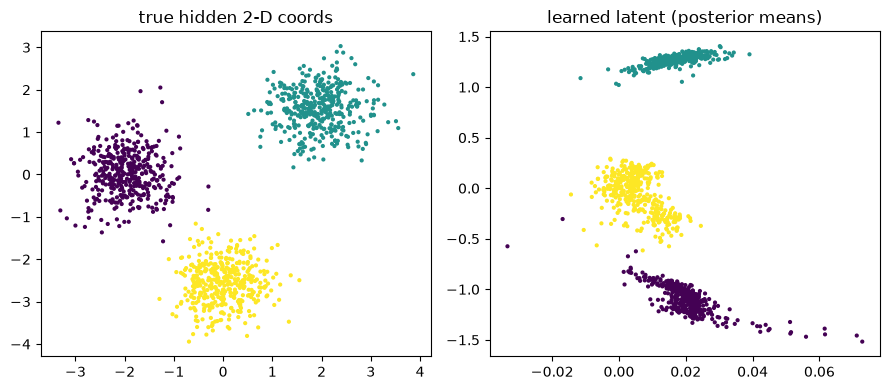

In [8]:
with torch.no_grad():
    mu_all, logvar_all = vae.encoder(X)

print("latent mean  :", mu_all.mean(0).tolist())
print("latent std   :", mu_all.std(0).tolist())
for c in range(3):
    print(f"cluster {c} latent centre:", [round(v, 2) for v in mu_all[cluster_id == c].mean(0).tolist()])

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].scatter(z_true[:, 0], z_true[:, 1], c=cluster_id, s=4, cmap="viridis"); ax[0].set_title("true hidden 2-D coords")
ax[1].scatter(mu_all[:, 0], mu_all[:, 1], c=cluster_id, s=4, cmap="viridis"); ax[1].set_title("learned latent (posterior means)")
plt.tight_layout(); plt.show()

### 9. Generating new data and interpolating

**What this cell does (plain language):** we use the trained VAE as a generator: draw `z ~ N(0, I)`, decode, and compare simple statistics of the generated data to the real data. Then we interpolate linearly in latent space between the posterior means of two real points from different clusters and decode every step; the decoded path is continuous, but its steps are not necessarily uniform: a large step usually marks where the path crosses the low-density gap between two clusters, where the decoder changes fastest.

In [9]:
torch.manual_seed(3)
gen = vae.sample(2000)
print("real mean/std of features (first 3):", X.mean(0)[:3].tolist(), X.std(0)[:3].tolist())
print("gen  mean/std of features (first 3):", [round(v, 2) for v in gen.mean(0)[:3].tolist()], [round(v, 2) for v in gen.std(0)[:3].tolist()])

# interpolate between a point of cluster 0 and one of cluster 1
a, c = X[cluster_id == 0][0], X[cluster_id == 1][0]
with torch.no_grad():
    za, zc = vae.encoder(a[None])[0], vae.encoder(c[None])[0]
    ts = torch.linspace(0, 1, 6)[:, None]
    path = vae.decoder((1 - ts) * za + ts * zc)
step_sizes = (path[1:] - path[:-1]).norm(dim=1)
print("distance between consecutive decoded points:", [round(v, 2) for v in step_sizes.tolist()])
print("endpoint recon error (a):", (path[0] - a).norm().item())

real mean/std of features (first 3): [1.5894572324981482e-09, 4.76837147544984e-09, -4.76837147544984e-09] [1.0, 0.9999999403953552, 1.0]
gen  mean/std of features (first 3): [-0.03, 0.0, -0.02] [0.89, 0.93, 0.91]
distance between consecutive decoded points: [1.01, 1.66, 1.39, 4.1, 0.03]
endpoint recon error (a): 0.7528735399246216


### 10. The beta trade-off and posterior collapse

**What this cell does (plain language):** we train three models that differ only in `beta`, the KL weight. With `beta` near 0 it is practically a plain autoencoder (great reconstruction, KL huge, latent space unregularised, samples from the prior are poor). With a very large `beta` the posterior is forced onto the prior and the latent carries almost no information about `x` ("posterior collapse"): reconstruction becomes poor because the decoder can only output something close to the average. We also count *active units*: latent dimensions whose posterior mean varies across the data.

In [10]:
results = {}
for beta in [0.01, 1.0, 20.0]:
    torch.manual_seed(0)
    m = VAE(D); opt = torch.optim.Adam(m.parameters(), lr=3e-3)
    for ep in range(40):
        perm = torch.randperm(len(X))
        for i in range(0, len(X), 128):
            xb = X[perm[i:i + 128]]
            xh, mu_, lv_ = m(xb)
            loss, _, _ = neg_elbo(xb, xh, mu_, lv_, beta)
            opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        xh, mu_, lv_ = m(X)
        _, r, k = neg_elbo(X, xh, mu_, lv_, 1.0)
        active = int((mu_.var(0) > 0.01).sum())
    results[beta] = (r.item(), k.item(), active)
    print(f"beta={beta:6.2f} | recon {r.item():7.3f} | KL {k.item():7.3f} | active latent dims {active}/2")

beta=  0.01 | recon   0.038 | KL   5.539 | active latent dims 2/2


beta=  1.00 | recon   0.474 | KL   1.184 | active latent dims 1/2


beta= 20.00 | recon   3.999 | KL   0.000 | active latent dims 0/2


## Common bugs

- **Sampling without reparameterisation** (`Normal(mu, std).sample()` or `torch.normal(mu, std)` inside the model)
  The encoder gets no gradient, so only the decoder learns.
  Fix: `z = mu + std * torch.randn_like(std)` or `.rsample()`.
- **Predicting `sigma` directly instead of `logvar`**
  The output can go negative or hit zero, giving `nan` in the KL / `log`.
  Fix: predict `logvar` and use `std = exp(0.5 * logvar)` (note the `0.5`; forgetting it squares the std).
- **Mean-reducing the reconstruction but sum-reducing the KL (or vice versa)**
  The effective `beta` silently changes by a factor of the feature count, which often causes posterior collapse or ignored KL.
  Fix: use the same reduction for both (sum over features/latents, then mean over the batch) and tune `beta` explicitly.
- **Forgetting the sign: minimising the ELBO instead of the negative ELBO**
  The loss goes down but the model gets worse (or diverges).
  Fix: loss = reconstruction + beta * KL, i.e. `-ELBO`.
- **Summing KL over the batch but averaging reconstruction over the batch**
  Loss scale depends on batch size. Fix: take `.mean()` over the batch for both terms.
- **Using `torch.no_grad()` or `.detach()` on `mu`/`logvar` before sampling**
  Silently disconnects the encoder. Fix: keep the graph through `reparameterize`; only no_grad when *generating*.
- **Sampling `z` at evaluation time and expecting deterministic outputs**
  Reconstructions change run to run. Fix: decode `mu` for deterministic evaluation; use the seed only for generation.
- **Sigmoid + MSE on unbounded data (or no sigmoid with BCE)**
  Match the decoder likelihood to the data: Gaussian (MSE) for real-valued data, Bernoulli (BCE with logits) for data in [0, 1].

## Exercises

Attempt each one in the empty cell right after it, then compare with the solution below.

**Exercise 1 - Verify KL against a Monte Carlo estimate.**
Check numerically that the closed-form KL equals `E_q[log q(z) - log p(z)]` estimated from 200k samples, for `mu=[1.0, -0.5]`, `logvar=[0.3, -0.7]`.

In [11]:
# Your attempt for Exercise 1 here

**Solution 1**

In [12]:
# Solution 1
torch.manual_seed(0)
mu = torch.tensor([1.0, -0.5]); logvar = torch.tensor([0.3, -0.7])
q = torch.distributions.Normal(mu, (0.5 * logvar).exp())
p = torch.distributions.Normal(torch.zeros(2), torch.ones(2))
z = q.sample((200_000,))
mc = (q.log_prob(z) - p.log_prob(z)).sum(-1).mean()
print("closed form:", kl_standard_normal(mu, logvar).item(), "| Monte Carlo:", mc.item())

closed form: 0.7482220530509949 | Monte Carlo: 0.7457237243652344


**Exercise 2 - Gradient through sample() vs rsample().**
Show that `rsample()` gives `mu.grad` while `sample()` leaves `mu.grad` as `None` after `backward()` on a loss built from the sample (wrap the `sample()` case so the loss has no graph; use `try/except`).

In [13]:
# Your attempt for Exercise 2 here

**Solution 2**

In [14]:
# Solution 2
mu = torch.tensor([0.0], requires_grad=True)
d = torch.distributions.Normal(mu, torch.tensor([1.0]))
(d.rsample() ** 2).sum().backward()
print("rsample grad:", mu.grad)
mu.grad = None
try:
    (d.sample() ** 2).sum().backward()
except RuntimeError as e:
    print("sample() -> RuntimeError (no graph):", str(e)[:60])
print("mu.grad after sample():", mu.grad)

rsample grad: tensor([3.0469])
sample() -> RuntimeError (no graph): element 0 of tensors does not require grad and does not have
mu.grad after sample(): None


**Exercise 3 - Free bits.**
Implement a KL with 'free bits': clamp the per-dimension KL below at `lam=0.5` nats (averaged over the batch) before summing, so dimensions are not pushed below `lam`. Return the value for a random batch.

In [15]:
# Your attempt for Exercise 3 here

**Solution 3**

In [16]:
# Solution 3
def kl_free_bits(mu, logvar, lam=0.5):
    kl_dim = 0.5 * (mu.pow(2) + logvar.exp() - logvar - 1)   # (batch, latent)
    kl_dim = kl_dim.mean(0)                                   # per-dim, batch-averaged
    return torch.clamp(kl_dim, min=lam).sum()
torch.manual_seed(0)
print(kl_free_bits(0.1 * torch.randn(32, 4), 0.1 * torch.randn(32, 4)).item(), "(each of 4 dims is floored at 0.5 -> 2.0)")

2.0 (each of 4 dims is floored at 0.5 -> 2.0)


**Exercise 4 - Train a 1-D latent VAE and compare.**
Train `VAE(D, latent=1)` for 40 epochs with beta=1 and report its final reconstruction term. Is it worse than the 2-D latent model, as expected for a 2-D manifold?

In [17]:
# Your attempt for Exercise 4 here

**Solution 4**

In [18]:
# Solution 4
torch.manual_seed(0)
m1 = VAE(D, latent=1); opt = torch.optim.Adam(m1.parameters(), lr=3e-3)
for ep in range(40):
    perm = torch.randperm(len(X))
    for i in range(0, len(X), 128):
        xb = X[perm[i:i+128]]
        xh, mu_, lv_ = m1(xb)
        loss, _, _ = neg_elbo(xb, xh, mu_, lv_)
        opt.zero_grad(); loss.backward(); opt.step()
with torch.no_grad():
    xh, mu_, lv_ = m1(X); _, r1, k1 = neg_elbo(X, xh, mu_, lv_)
    xh, mu_, lv_ = vae(X); _, r2, k2 = neg_elbo(X, xh, mu_, lv_)
print(f"1-D latent recon {r1.item():.3f} | 2-D latent recon {r2.item():.3f}")

1-D latent recon 0.594 | 2-D latent recon 0.531


**Exercise 5 - KL annealing schedule.**
Write a function `beta_at(step, warmup)` that ramps beta linearly from 0 to 1 over `warmup` steps and stays at 1. Print its value at several steps.

In [19]:
# Your attempt for Exercise 5 here

**Solution 5**

In [20]:
# Solution 5
def beta_at(step, warmup=100):
    return min(1.0, step / warmup)
print([beta_at(s) for s in [0, 25, 50, 100, 500]])

[0.0, 0.25, 0.5, 1.0, 1.0]


**Exercise 6 - Deterministic reconstruction.**
Compute reconstruction error using (a) a sampled `z` and (b) `z = mu` on the full dataset with the trained `vae`. Which is lower, and why?

In [21]:
# Your attempt for Exercise 6 here

**Solution 6**

In [22]:
# Solution 6
with torch.no_grad():
    mu_, lv_ = vae.encoder(X)
    err_sample = (vae.decoder(vae.reparameterize(mu_, lv_)) - X).pow(2).sum(-1).mean()
    err_mean = (vae.decoder(mu_) - X).pow(2).sum(-1).mean()
print("sampled z:", err_sample.item(), "| z = mu:", err_mean.item())
print("Using mu is typically lower: sampling adds noise of size sigma that the decoder must tolerate.")

sampled z: 1.0050976276397705 | z = mu: 0.36466801166534424
Using mu is typically lower: sampling adds noise of size sigma that the decoder must tolerate.
